# **DATASET DESCRIPTION**

**Dataset Path:** `Data/country_data.csv`

---

This dataset contains socio-economic and health indicators for **167 countries**. Our goal is to categorize these countries into clusters that represent different levels of development.

### **Variables**

| Variable | Description | Type |
|----------|-------------|------|
| `country` | Name of the country | Categorical (identifier) |
| `child_mort` | Death of children under 5 years of age per 1000 live births | Continuous |
| `exports` | Exports of goods and services per capita (% of GDP) | Continuous |
| `health` | Total health spending per capita (% of GDP) | Continuous |
| `imports` | Imports of goods and services per capita (% of GDP) | Continuous |
| `income` | Net income per person | Continuous |
| `inflation` | Annual growth rate of Total GDP (%) | Continuous |
| `life_expec` | Average number of years a newborn child would live | Continuous |
| `total_fer` | Number of children that would be born to each woman | Continuous |
| `gdpp` | GDP per capita | Continuous |

### Data Loading and Initial Exploration

In [55]:
df = pd.read_csv("C:/Users/Ezgi/Downloads/country_data.csv")
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     177 non-null    object 
 1   child_mort  177 non-null    float64
 2   exports     177 non-null    float64
 3   health      177 non-null    float64
 4   imports     177 non-null    float64
 5   income      177 non-null    int64  
 6   inflation   177 non-null    float64
 7   life_expec  177 non-null    float64
 8   total_fer   177 non-null    float64
 9   gdpp        177 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 14.0+ KB


country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Developed countries have typically high income levels, low child mortality rates, high life expectancy, and strong health and education indicators. They have more access to healthcare, a more stablel economy and better standards of living. Some countries show moderate income levels and an improving health indictaors but doesn't achieve the standards of developed countries yet, which puts them into the intermediate development group. The most specific variables for distinguishing country development are life expectancy, incomei and child mortality.

### Data Loading and Visualization
Loading the dataset and performing initial exploration:
1. Creating correlation heatmap
2. Creating scatter plots showing relationship between variables
3. Visualizing the relationships between features by displaying their pairwise correlation values in a heatmap.

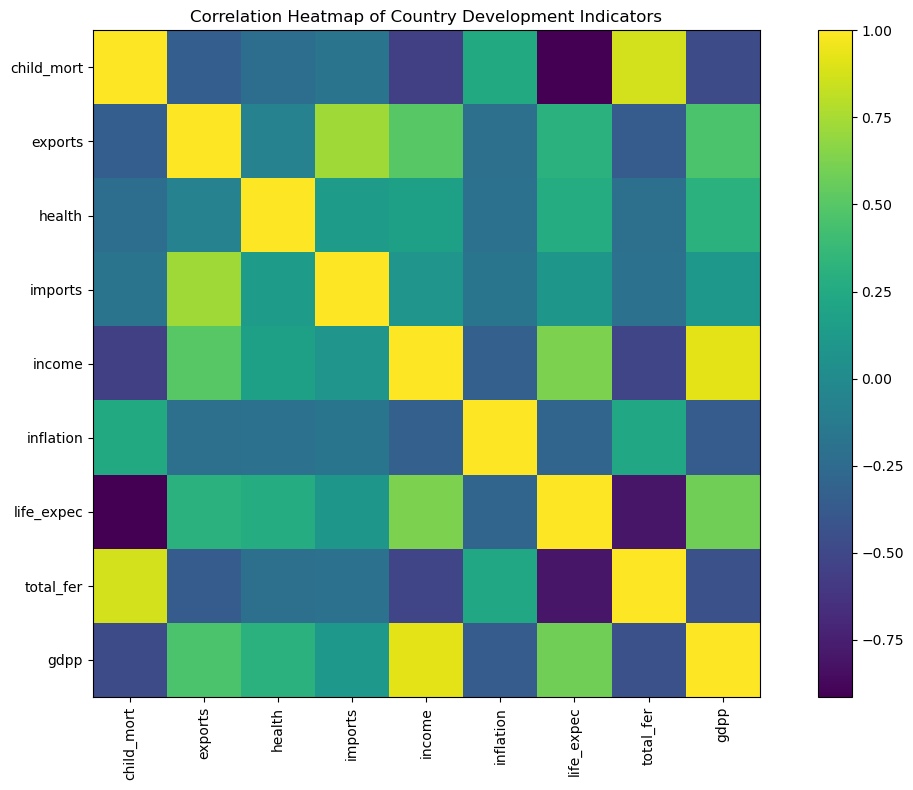

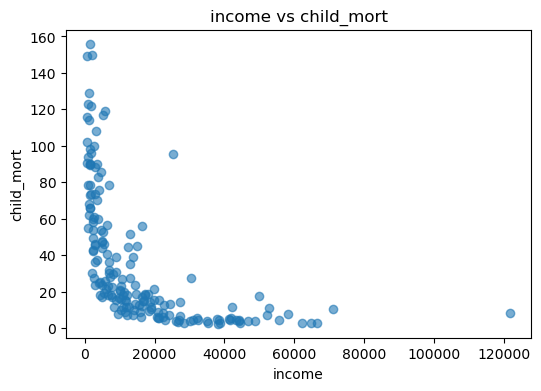

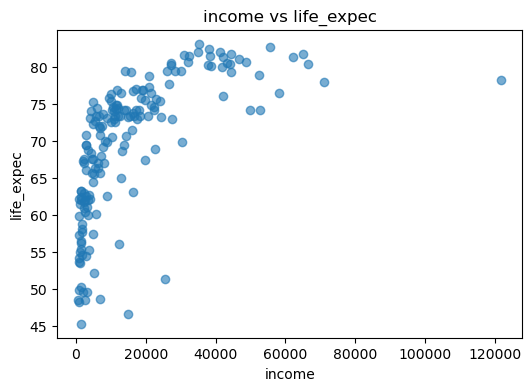

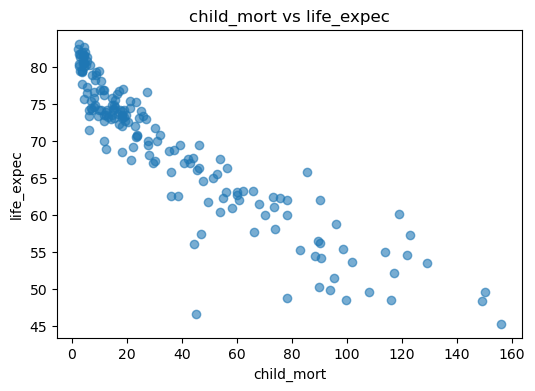

In [ ]:
numeric_df = df.select_dtypes(include = ['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Country Development Indicators")
plt.tight_layout()
plt.show()
pairs = [
    ("income", "child_mort"),
    ("income", "life_expec"),
    ("child_mort", "life_expec")
]
for x_var, y_var in pairs:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[x_var], df[y_var], alpha=0.6)
    plt.xlabel(x_var)
    plt.ylabel(y_var)
    plt.title(f"{x_var} vs {y_var}")
    plt.show()

We can see from the heat correlation map that the death of children under the age of 5 is highly correlated with the number of children that would be born to each woman and GDP per capital is highly correlated with the income of each person.

  ### Data Preprocessing

In [ ]:
missing_values = numeric_df.isnull().sum()
numeric_df = numeric_df.fillna(numeric_df.mean())
for col in numeric_df.columns:
    Q1 = numeric_df[col].quantile(0.25)
    Q3 = numeric_df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    numeric_df[col] = numeric_df[col].clip(lower_bound, upper_bound)
scaled_df = (numeric_df - numeric_df.mean())/numeric_df.std()
scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.593368,-1.415532,0.386636,-0.088327,-0.945544,0.983818,-1.430232,1.981288,-0.863635
1,-0.555047,-0.564112,-0.014181,0.094323,-0.367168,-0.218576,0.734373,-0.868223,-0.527641
2,-0.242709,-0.072181,-0.940339,-0.754754,-0.160705,2.601585,0.755911,-0.020886,-0.492493
3,2.434053,1.058315,-1.454007,-0.187057,-0.647319,2.842064,-1.010234,2.213622,-0.580838
4,-0.738947,0.263657,-0.216535,0.602783,0.270297,-0.959445,0.788219,-0.540221,0.242759


Outliers are identified using the IQR method in order not to remove the outlier observations. Instead, these values were capped at the lower and upper IQR bounds. This method was used because exxtreme values in country development data often respresent meaningful conditions, such as very low child mortality or very high income. Removing those values could eliminate important information.
Feature sacaling is essential for K-means because it relies on Euclidean distance. Without feature scaling, features with large numeric ranges would dominate distance calculations, causing the clsutering to ignore other important indicatos. By scaling the data, we make sure that al features contribute equally and we get more balanced clusters.

### Applying K-Means Clustering To The Preprocessed Data

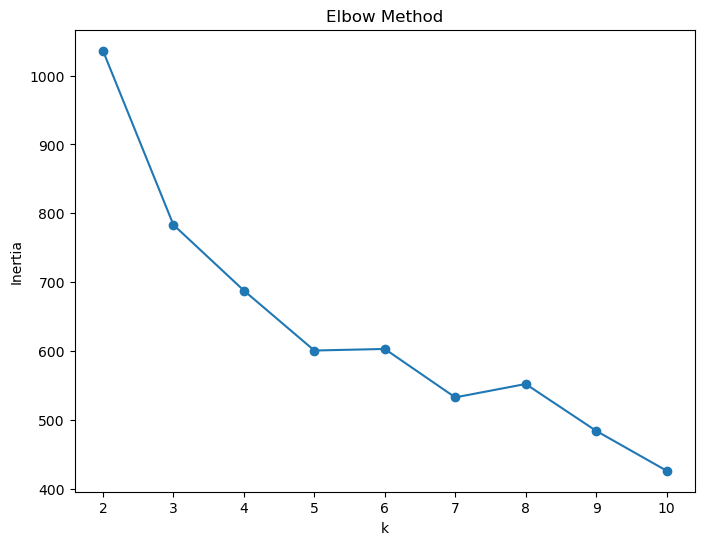

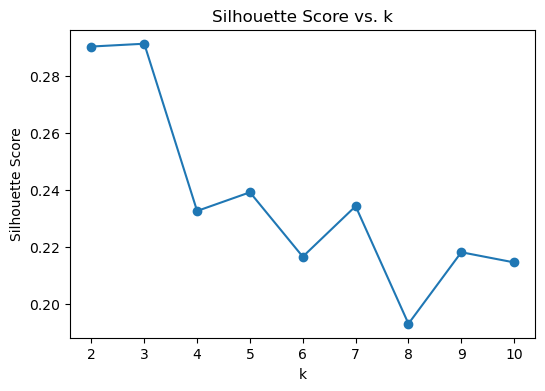

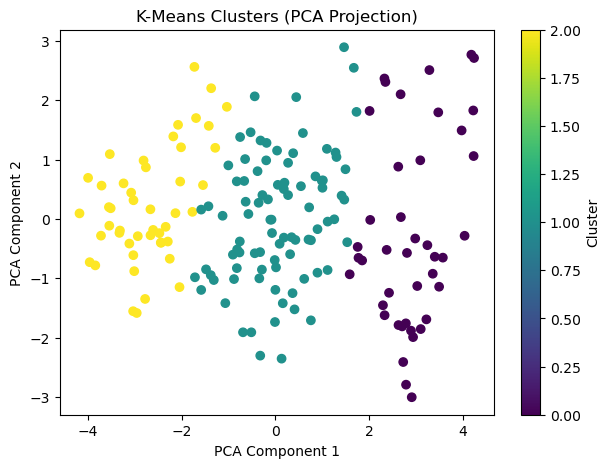


Cluster 0:
['Australia' 'Austria' 'Bahamas' 'Belgium' 'Brunei']

Cluster 1:
['Albania' 'Algeria' 'Antigua and Barbuda' 'Argentina' 'Armenia']

Cluster 2:
['Afghanistan' 'Angola' 'Benin' 'Botswana' 'Burkina Faso']


In [ ]:
def initialize_centroids(X, k):
    indices = np.random.choice(len(X), k, replace = False)
    return X[indices]
def assign_clusters(X, centroids):
    labels = []
    for x in X:
        distances = [euclidean_distance(x, c) for c in centroids]
        labels.append(np.argmin(distances))
    return np.array(labels)
def update_centroids(X, labels, k):
    centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        centroids.append(cluster_points.mean(axis=0))
    return np.array(centroids)
def kmeans(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids
def compute_inertia(X, labels, centroids):
    inertia = 0
    for i, x in enumerate(X):
        inertia += euclidean_distance(x, centroids[labels[i]]) ** 2
    return inertia
X = scaled_df.values
inertias = []
k_values = range(2, 11)

for k in k_values:
    labels, centroids = kmeans(X, k)
    inertia = compute_inertia(X, labels, centroids)
    inertias.append(inertia)

plt.figure(figsize=(8,6))
plt.plot(k_values, inertias, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()
def silhouette_score_manual(X, labels):
    scores = []

    for i in range(len(X)):
        same_cluster = X[labels == labels[i]]
        other_clusters = [X[labels == l] for l in np.unique(labels) if l != labels[i]]

        a = np.mean([euclidean_distance(X[i], x) for x in same_cluster if not np.array_equal(x, X[i])])

        b = min(
            np.mean([euclidean_distance(X[i], x) for x in cluster])
            for cluster in other_clusters
        )

        scores.append((b - a) / max(a, b))
    return np.mean(scores)
silhouette_scores = []

for k in k_values:
    labels, _ = kmeans(X, k)
    score = silhouette_score_manual(X, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs. k")
plt.show()
optimal_k = 3
final_labels, final_centroids = kmeans(X, optimal_k)
df["Cluster"] = final_labels

cov_matrix = np.cov(X.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvectors = eigenvectors[:, idx]

X_pca = X.dot(eigenvectors[:, :2])

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=final_labels, cmap="viridis")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()
for c in range(optimal_k):
    print(f"\nCluster {c}:")
    print(df[df["Cluster"] == c]["country"].head(5).values)


Number of clusters was chosen as k=3. The elbow method shows a bend at k=3, showing diminishing returns in inertia reduction beyond this point. Silhouette score also reaches one of its highest values around k=3.
Since clusters that appear overlapping in 2D may actually be seperated in higher dimensions, a 2D visualization can only represent a small portion of the total variance in a high-dimensional dataset.
Countries in the same cluster share similar development indicators. One cluster mainly has highly developed countries with high income and life expectancy, another includes developing countries with low income and high child mortality, and the third represents intermediate development countries. This grouping is consistent with real world expectations.

## Hierarchical Agglomerative Clustering

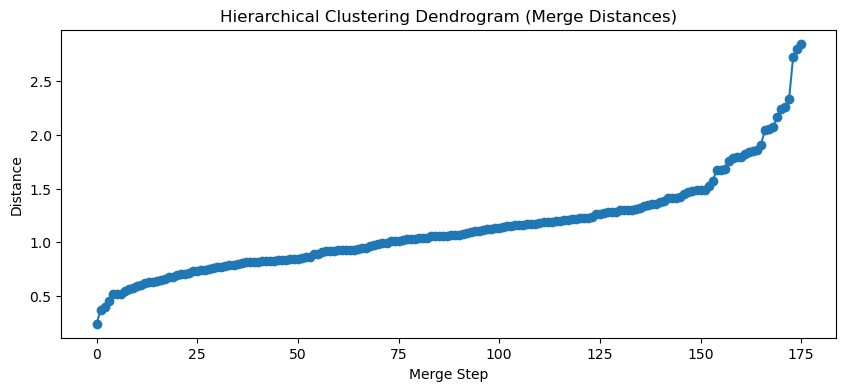

HAC_Cluster  0  1   2
Cluster              
0            0  0  42
1            0  0  88
2            1  1  45

HAC Cluster 0:
['Equatorial Guinea']

HAC Cluster 1:
['Sierra Leone']

HAC Cluster 2:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda']


In [ ]:
def pairwise_distance_matrix(X):
    n = len(X)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            dist = euclidean_distance(X[i], X[j])
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    return dist_matrix
def hierarchical_clustering(X):
    n = len(X)
    clusters = [[i] for i in range(n)]
    distances = pairwise_distance_matrix(X)
    merge_history = []

    while len(clusters) > 1:
        min_dist = np.inf
        pair = (0, 1)
        for i in range(len(clusters)):
            for j in range(i+1, len(clusters)):
                for a in clusters[i]:
                    for b in clusters[j]:
                        if distances[a, b] < min_dist:
                            min_dist = distances[a, b]
                            pair = (i, j)

        c1, c2 = pair
        new_cluster = clusters[c1] + clusters[c2]
        merge_history.append((clusters[c1], clusters[c2], min_dist))
        clusters.pop(max(c1, c2))
        clusters.pop(min(c1, c2))
        clusters.append(new_cluster)

    return merge_history
X = scaled_df.values
merge_history = hierarchical_clustering(X)
heights = [m[2] for m in merge_history]

plt.figure(figsize=(10, 4))
plt.plot(range(len(heights)), heights, marker='o')
plt.xlabel("Merge Step")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram (Merge Distances)")
plt.show()
def cut_clusters(merge_history, n_points, k):
    clusters = [[i] for i in range(n_points)]
    for merge in merge_history[:-k+1]:
        c1, c2, _ = merge
        idx1 = next(i for i,c in enumerate(clusters) if set(c1).issubset(c))
        idx2 = next(i for i,c in enumerate(clusters) if set(c2).issubset(c))

        new_cluster = clusters[idx1] + clusters[idx2]
        clusters.pop(max(idx1, idx2))
        clusters.pop(min(idx1, idx2))
        clusters.append(new_cluster)
    labels = np.zeros(n_points, dtype=int)
    for i, c in enumerate(clusters):
        for idx in c:
            labels[idx] = i
    return labels
optimal_k = 3
hac_labels = cut_clusters(merge_history, len(X), optimal_k)
df["HAC_Cluster"] = hac_labels
comparison = pd.crosstab(df["Cluster"], df["HAC_Cluster"])
print(comparison)
for c in range(3):
    print(f"\nHAC Cluster {c}:")
    print(df[df["HAC_Cluster"] == c]["country"].head(5).values)

## Applying PCA 

Components needed for 80% variance: 4
Components needed for 95% variance: 5


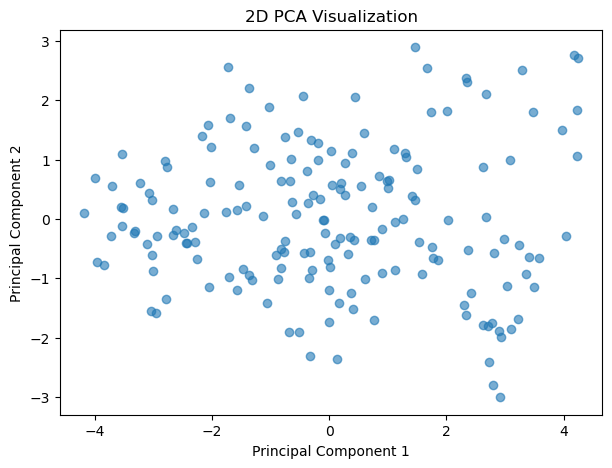

In [60]:
X = scaled_df.values
cov_matrix = np.cov(X.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
components_80 = np.argmax(cumulative_variance >= 0.80) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Components needed for 80% variance:", components_80)
print("Components needed for 95% variance:", components_95)
X_pca_2d = X.dot(eigenvectors[:, :2])

plt.figure(figsize=(7,5))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Visualization")
plt.show()

The visualization doesn't show clearly seperated natural groupings. This shows that although PCA captures the main directions of variance in the data, the first 2 components are not sufficient in seperating countries.

## K-Means Clustering with PCA

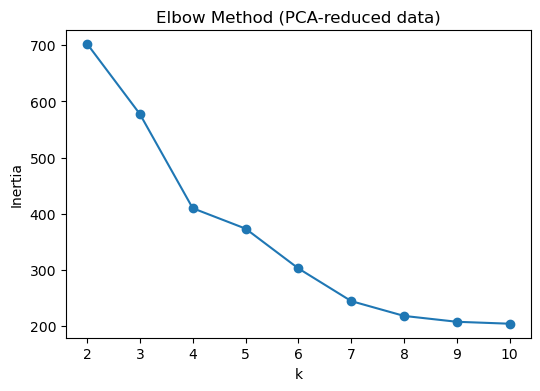

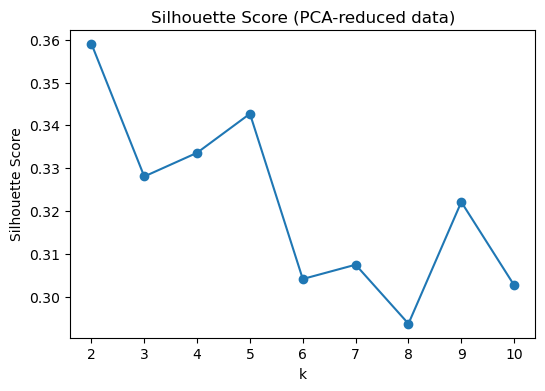

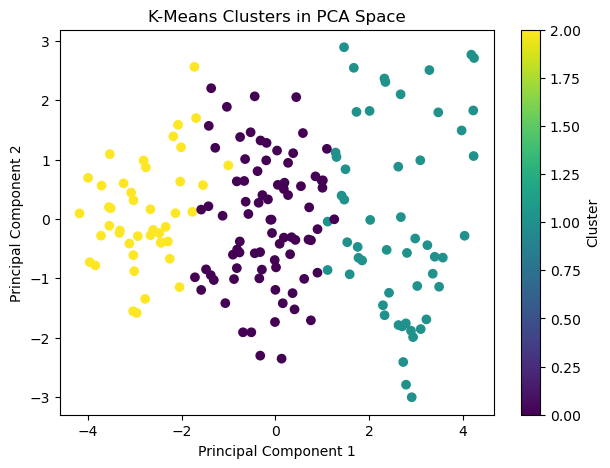

In [61]:
# implementation here
n_components = 3

X = scaled_df.values
X_pca = X.dot(eigenvectors[:, :n_components])
inertias_pca = []
k_values = range(2, 11)

for k in k_values:
    labels, centroids = kmeans(X_pca, k)
    inertia = compute_inertia(X_pca, labels, centroids)
    inertias_pca.append(inertia)

plt.figure(figsize=(6,4))
plt.plot(k_values, inertias_pca, marker='o')
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method (PCA-reduced data)")
plt.show()
silhouette_scores_pca = []

for k in k_values:
    labels, _ = kmeans(X_pca, k)
    score = silhouette_score_manual(X_pca, labels)
    silhouette_scores_pca.append(score)

plt.figure(figsize=(6,4))
plt.plot(k_values, silhouette_scores_pca, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score (PCA-reduced data)")
plt.show()
optimal_k_pca = 3
pca_labels, _ = kmeans(X_pca, optimal_k_pca)

df["PCA_KMeans_Cluster"] = pca_labels
plt.figure(figsize=(7,5))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=pca_labels,
    cmap="viridis"
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters in PCA Space")
plt.colorbar(label="Cluster")
plt.show()